In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv("/content/census-income .csv")
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [4]:
#problem statement-->1 how many hours works he or she working


In [5]:
#EDA
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [6]:
df.duplicated().sum()

np.int64(24)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.duplicated().sum()

np.int64(0)

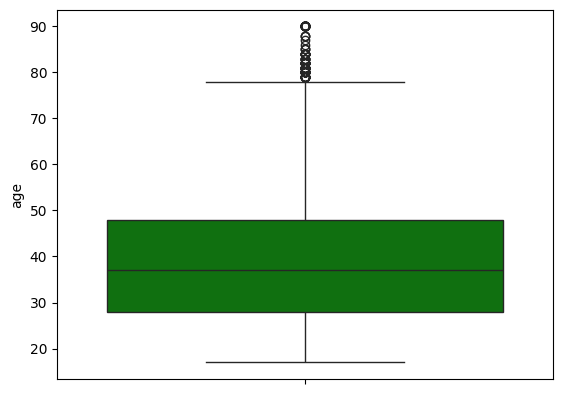

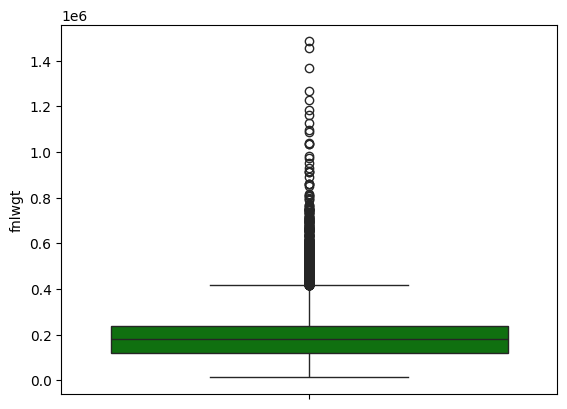

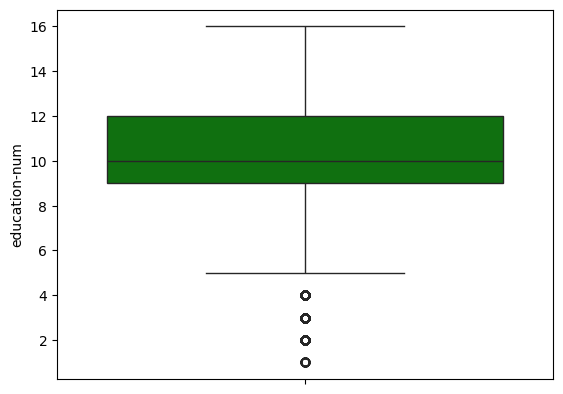

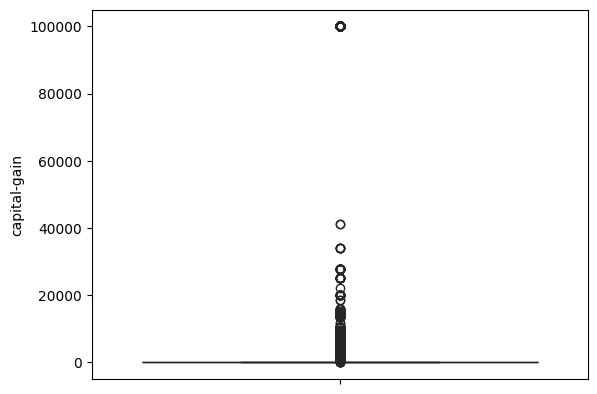

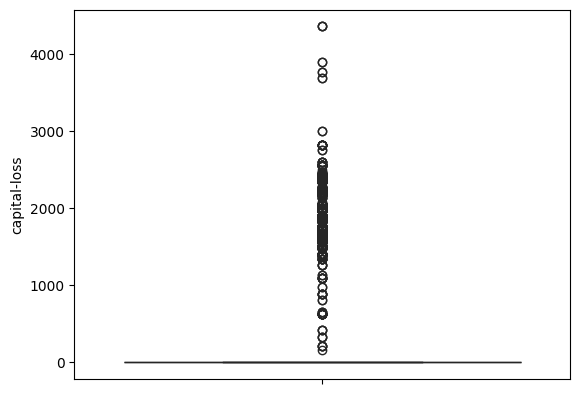

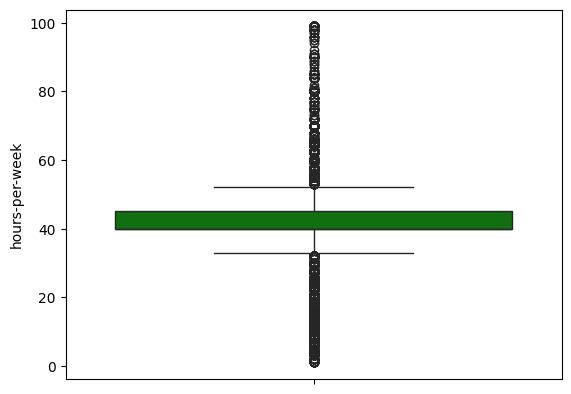

In [13]:
for col in df.columns:
  if df[col].dtype != "object":
    sns.boxplot(df[col],color ='green')
    plt.show()


In [14]:
out_liers=["age",'fnlwgt','education-num']#i have not considerd houres per week because of the targeted column
for col in out_liers:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  iqr=q3-q1
  LB=q1-1.5*iqr
  UB=q3+1.5*iqr
  df=df[(df[col] >LB) &(df[col]<UB)]

In [21]:
#Label encoding
from sklearn.preprocessing import LabelEncoder
Le=LabelEncoder()
for col in df.columns:
  if df[col].dtype =="object":
    df[col]=Le.fit_transform(df[col])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30287 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             30287 non-null  int64
 1   workclass       30287 non-null  int64
 2   fnlwgt          30287 non-null  int64
 3   education       30287 non-null  int64
 4   education-num   30287 non-null  int64
 5   marital-status  30287 non-null  int64
 6   occupation      30287 non-null  int64
 7   relationship    30287 non-null  int64
 8   race            30287 non-null  int64
 9   sex             30287 non-null  int64
 10  capital-gain    30287 non-null  int64
 11  capital-loss    30287 non-null  int64
 12  hours-per-week  30287 non-null  int64
 13  native-country  30287 non-null  int64
 14  annual_income   30287 non-null  int64
dtypes: int64(15)
memory usage: 3.7 MB


In [ ]:
#all int

In [31]:
x=df.drop("hours-per-week",axis=1)
y=df['hours-per-week']
x

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,native-country,annual_income
0,39,7,77516,6,13,4,1,1,4,1,2174,0,39,0
1,50,6,83311,6,13,2,4,0,4,1,0,0,39,0
2,38,4,215646,8,9,0,6,1,4,1,0,0,39,0
3,53,4,234721,1,7,2,6,0,2,1,0,0,39,0
4,28,4,338409,6,13,2,10,5,2,0,0,0,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,4,257302,4,12,2,13,5,4,0,0,0,39,0
32557,40,4,154374,8,9,2,7,0,4,1,0,0,39,1
32558,58,4,151910,8,9,6,1,4,4,0,0,0,39,0
32559,22,4,201490,8,9,4,1,3,4,1,0,0,39,0


In [32]:
y

,hours-per-week
0,40
1,13
2,40
3,40
4,40
...,...
32556,38
32557,40
32558,40
32559,20


In [33]:
#split data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train



,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,native-country,annual_income
9592,53,4,213378,8,9,5,12,1,4,0,0,0,39,0
31240,27,6,120126,11,10,2,4,0,4,1,0,0,39,0
11615,59,4,91384,7,16,2,10,0,4,1,0,0,39,1
24638,49,4,187454,8,9,2,12,0,4,1,99999,0,39,1
21106,43,4,178976,8,9,4,1,4,4,0,0,0,39,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32037,45,6,31478,6,13,2,12,0,4,1,2829,0,39,0
5797,22,4,206861,11,10,4,1,3,4,1,0,0,39,0
924,64,0,29825,8,9,2,0,0,4,1,0,0,39,0
16964,45,2,209482,9,14,2,10,5,4,0,0,0,39,1


In [27]:
x_test

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,native-country,annual_income
22436,31,4,113838,6,13,2,10,0,4,1,0,0,39,0
17109,25,4,190350,8,9,4,1,4,2,0,0,0,39,0
29767,33,4,226267,4,12,2,12,0,4,1,0,0,26,0
23388,62,0,113234,9,14,2,0,5,4,0,0,0,39,0
18266,57,4,162301,8,9,0,1,1,4,0,0,0,39,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1719,38,4,187069,8,9,2,14,0,4,1,0,0,39,0
12979,45,4,84298,5,11,2,4,0,4,1,0,1977,39,1
32210,31,4,284395,6,13,2,12,0,4,1,0,0,39,0
11484,69,0,182668,8,9,2,0,0,4,1,0,0,39,1


In [34]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)


LinearRegression()

In [43]:
pre_ans=model.predict(x_test)

In [50]:
print(pre_ans[:5])   # predicted


[40.69871837 43.17549271 46.74941678 42.82853237 37.84932608]


In [48]:
print(y_test[:5])    # actual

7616     37
11372    45
240      40
13611    30
28617    30
Name: hours-per-week, dtype: int64


In [51]:
import pandas as pd

result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": pre_ans
})

print(result.head())

   Actual  Predicted
0      37  40.698718
1      45  43.175493
2      40  46.749417
3      30  42.828532
4      30  37.849326


In [54]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("R2 Score:", r2_score(y_test, pre_ans))
print("MAE:", mean_absolute_error(y_test, pre_ans))
print("MSE:", mean_squared_error(y_test, pre_ans))

R2 Score: 0.1445565967759842
MAE: 7.858393824870394
MSE: 130.18400332396044


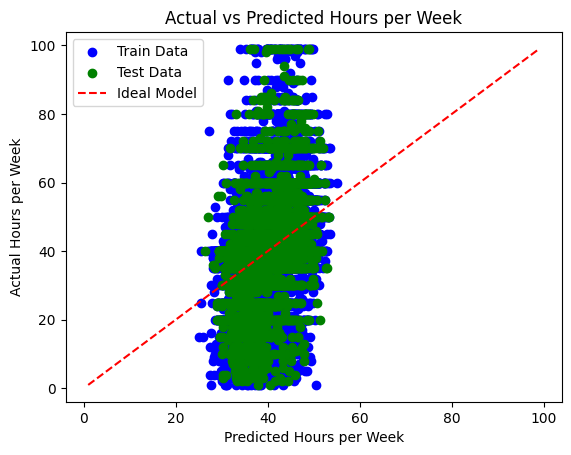

In [56]:
import matplotlib.pyplot as plt

# Get predictions for training data
train_predictions = model.predict(x_train)

# Training data: Predicted vs Actual
plt.scatter(train_predictions, y_train, color="blue", label="Train Data")

# Test data: Predicted vs Actual
plt.scatter(pre_ans, y_test, color="green", label="Test Data")

# Ideal prediction line (y=x)
# Find min/max values across both actual and predicted to set line bounds
min_val = min(y_test.min(), pre_ans.min(), y_train.min(), train_predictions.min())
max_val = max(y_test.max(), pre_ans.max(), y_train.max(), train_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle='--', label="Ideal Model")

plt.xlabel("Predicted Hours per Week")
plt.ylabel("Actual Hours per Week")
plt.title("Actual vs Predicted Hours per Week")
plt.legend()
plt.show()

In [ ]:
'''Your model is not performing well. It is not able to predict values close to the real answers.
The R² value is very low, which means the model is not understanding the pattern in the data properly.
The MAE value shows that your predictions are off by around 8 units on average, which is quite high.
The MSE value is also large, meaning some predictions are very far from the actual values.
This problem can happen because the data is not clean, important features are missing,
or the model you used is too simple for this problem. Overall, the model needs improvement to give better and more accurate predictions.'''


In [57]:
#1. Check correlation
df.corr()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
age,1.000000,0.017098,-0.060755,0.015934,0.110989,-0.294386,-0.013688,-0.268883,0.036073,0.096158,0.083416,0.058788,0.102903,-0.002657,0.259068
workclass,0.017098,1.000000,-0.017665,0.020101,0.056549,-0.063736,0.242939,-0.094137,0.050087,0.097687,0.033145,0.011676,0.135620,-0.005740,0.049519
fnlwgt,-0.060755,-0.017665,1.000000,-0.013699,-0.019575,0.028249,0.000984,0.005787,-0.010404,0.020895,0.002120,-0.000690,-0.018878,-0.038224,0.000369
education,0.015934,0.020101,-0.013699,1.000000,0.211403,-0.029526,-0.028643,-0.013377,0.013470,-0.019492,0.020654,0.012010,0.040649,0.026189,0.042797
education-num,0.110989,0.056549,-0.019575,0.211403,1.000000,-0.069598,0.123562,-0.127558,0.034287,0.033118,0.128324,0.089181,0.163349,-0.041709,0.342462
marital-status,-0.294386,-0.063736,0.028249,-0.029526,-0.069598,1.000000,-0.008269,0.183562,-0.067184,-0.124944,-0.043769,-0.034753,-0.190075,-0.017436,-0.201278
occupation,-0.013688,0.242939,0.000984,-0.028643,0.123562,-0.008269,1.000000,-0.080510,0.009332,0.084460,0.024420,0.017121,0.079541,-0.011118,0.075675
relationship,-0.268883,-0.094137,0.005787,-0.013377,-0.127558,0.183562,-0.080510,1.000000,-0.114992,-0.584103,-0.058570,-0.061431,-0.260850,-0.006854,-0.257770
race,0.036073,0.050087,-0.010404,0.013470,0.034287,-0.067184,0.009332,-0.114992,1.000000,0.085523,0.009965,0.020791,0.043081,0.153286,0.071983
sex,0.096158,0.097687,0.020895,-0.019492,0.033118,-0.124944,0.084460,-0.584103,0.085523,1.000000,0.048972,0.047710,0.235676,-0.005133,0.223451


In [ ]:
'''The model is not performing well because most of the input features have a weak relationship with the target variable,
 which is hours-per-week. In correlation terms, values close to 1 or -1 are strong (good),
 and values close to 0 are weak (bad). In this dataset, most values are near 0,
  which means they have a bad or weak correlation with hours-per-week. Because of this,
  the model cannot learn proper patterns and gives poor predictions.
  This results in a low R² score and high error values like MAE and MSE.
  Overall, the model is weak because the data does not strongly support predicting working hours.'''